# Introduction to Matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import sklearn

[]

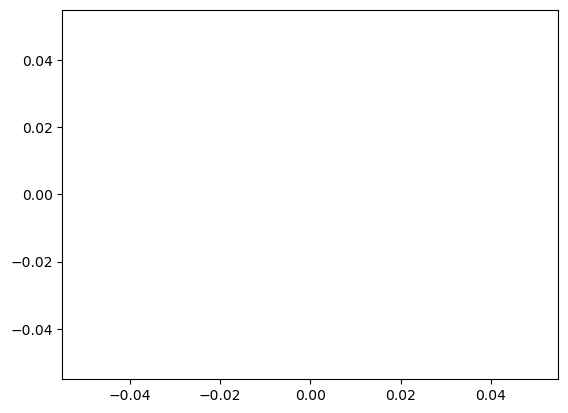

In [2]:
# Creates our plot
plt.plot()

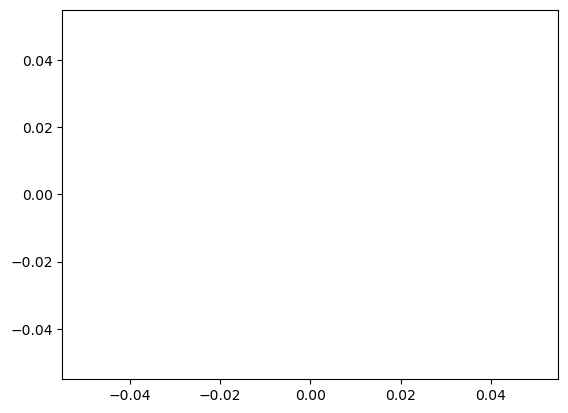

In [3]:
# Terminating our expression with a semicolon **removes** 
# the empty brackets printed otherwise.
plt.plot();

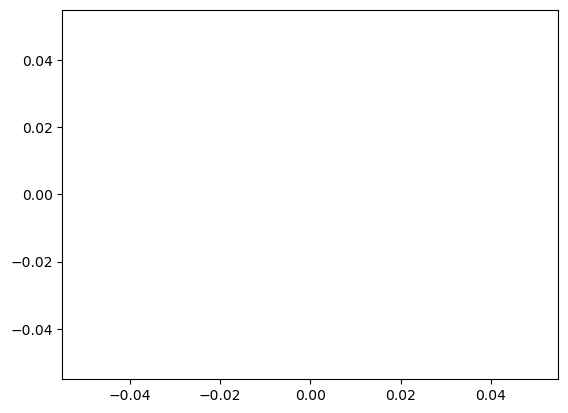

In [4]:
plt.plot()
plt.show()

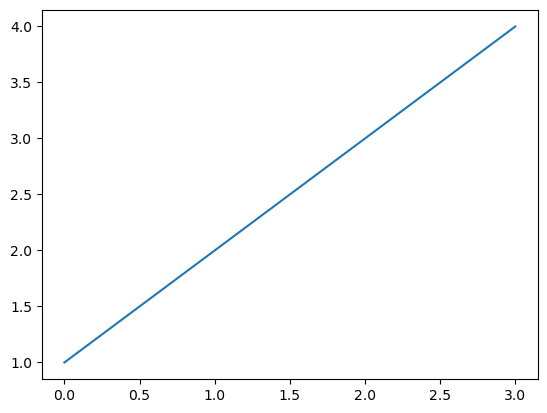

In [5]:
# Plot y-values, `(1, 2, 3, 4)` against implied x-values, `(0, 1, 2, 3)`.
plt.plot([1, 2, 3, 4]);

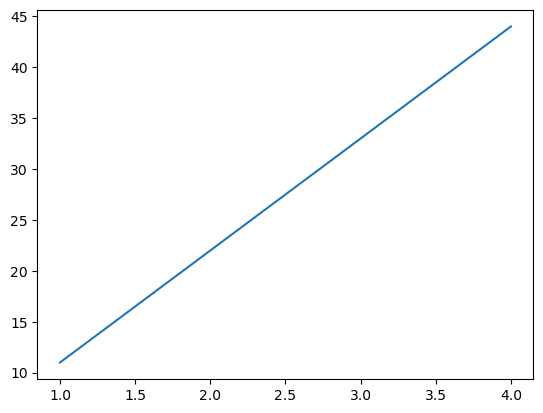

In [6]:
# Specify x- and y-values for plotting.
x = [1, 2, 3, 4]
y = [11, 22, 33, 44]
plt.plot(x, y);

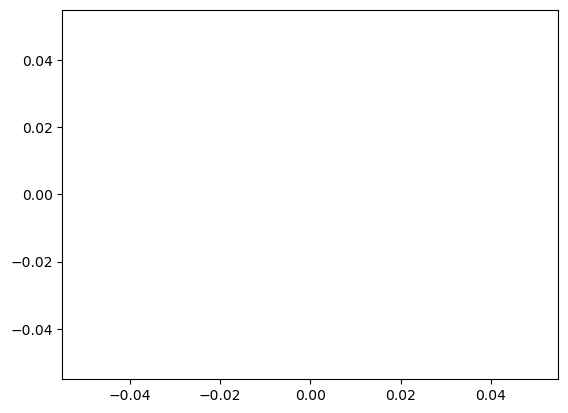

In [7]:
plt.plot();

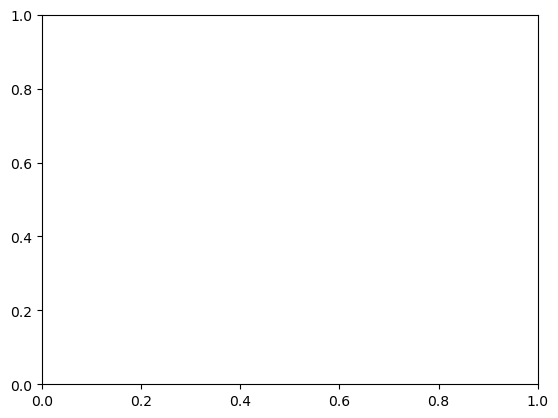

In [8]:
# First method
fig = plt.figure()  # creates a figure
ax = fig.add_subplot()  # adds axes (**not** plural of 'axis')
plt.show()

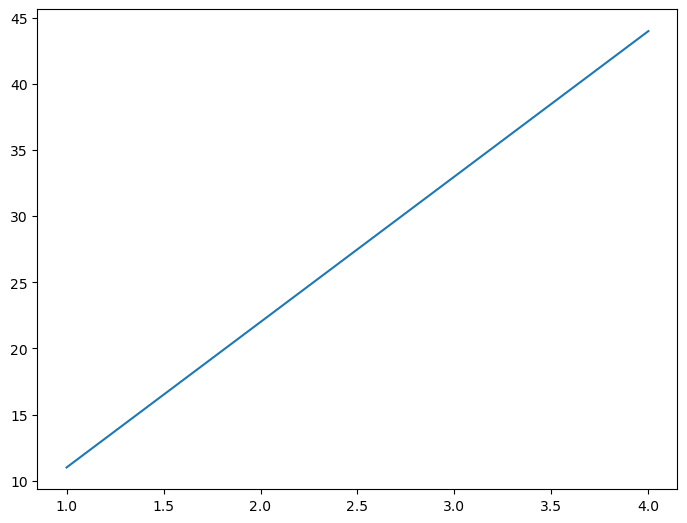

In [9]:
# Second method
fig = plt.figure()  # cerates a figure
ax = fig.add_axes([1, 1, 1, 1])  # axes with a bounding rectangle
ax.plot(x, y)
plt.show()

(matplotlib.figure.Figure, matplotlib.axes._axes.Axes)

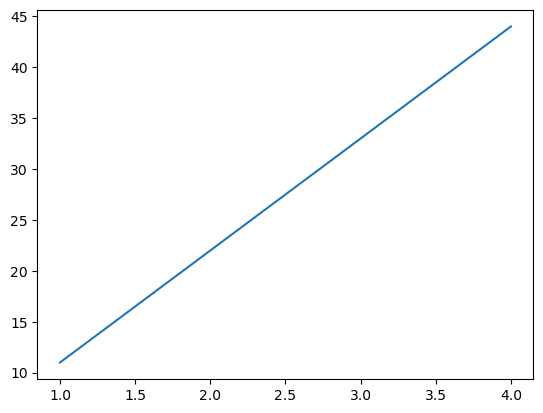

In [10]:
# Third method (recommended)
fig, ax = plt.subplots()  ## creates a figure and associated subplots (each with its own axes)
ax.plot(x, y);
type(fig), type(ax)

# Note that one can **regenerate** the plot simply by changing the 
# x- or y-values supplied to `ax.plot()` and running the cell.

## Matplotlib example workflow

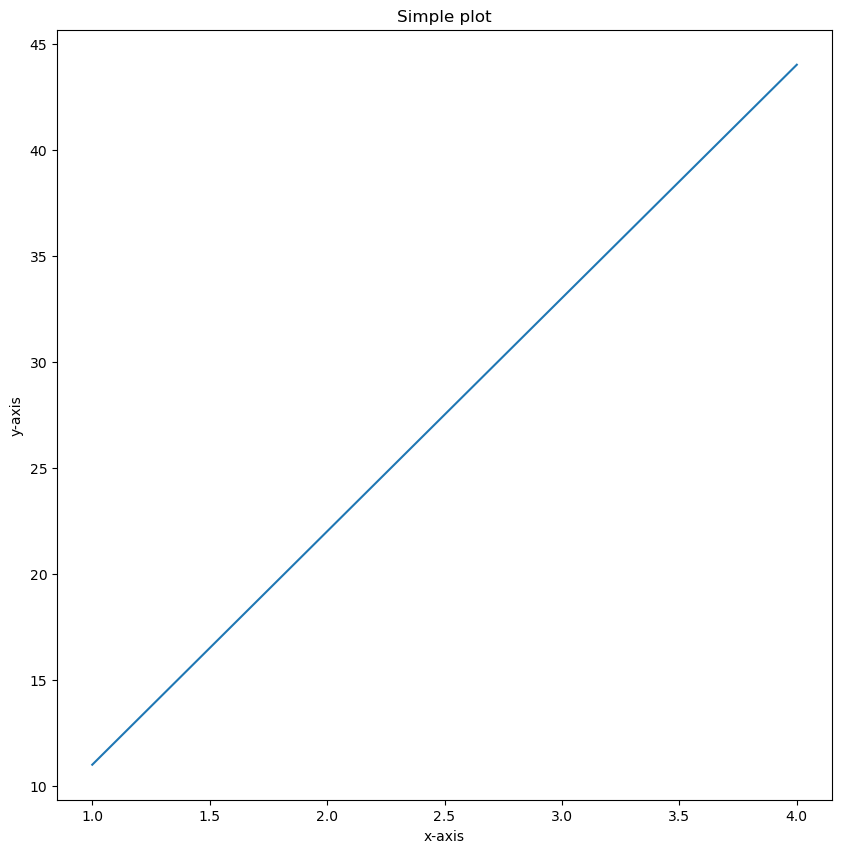

In [11]:
# 0. Import matplotlib and get it ready for plotting in Jupyter
# We will duplicate previous code in a single cell
import matplotlib.pyplot as plt

# 1. Prepare some dataA
x = [1, 2, 3, 4]
y = [11, 22, 33, 44]

# 2. Set up plot
fix, ax = plt.subplots(figsize=(10, 10)) # (width, height)

# 3. Plot data
ax.plot(x, y)  # plot curves y against x

# 4. Customize plot
ax.set(title="Simple plot",
       xlabel="x-axis",
       ylabel="y-axis")

# 5. Save and show (you save the whole figure)
fig.savefig('images/sample-plot.png')

## Making figures with NumPy arrays

We want:
- Line plot
- Scatter plot
- Bar plot
- Histogram
- (Subplot - not really a "type" of plot)

In [12]:
import numpy as np

In [13]:
# Create some data
x = np.linspace(0, 10, 100)
x[:10], x[-10:]

(array([0.        , 0.1010101 , 0.2020202 , 0.3030303 , 0.4040404 ,
        0.50505051, 0.60606061, 0.70707071, 0.80808081, 0.90909091]),
 array([ 9.09090909,  9.19191919,  9.29292929,  9.39393939,  9.49494949,
         9.5959596 ,  9.6969697 ,  9.7979798 ,  9.8989899 , 10.        ]))

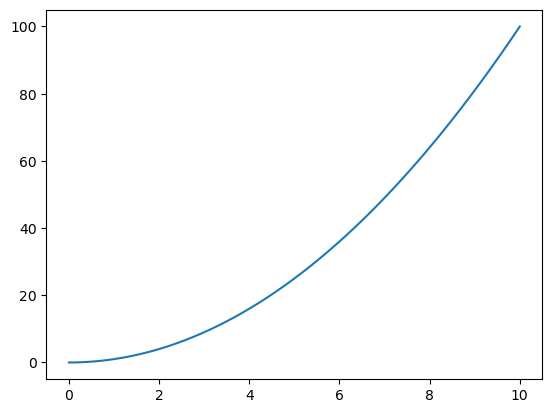

In [14]:
# Plot the data
fig, ax = plt.subplots()
ax.plot(x, x**2)
plt.show()

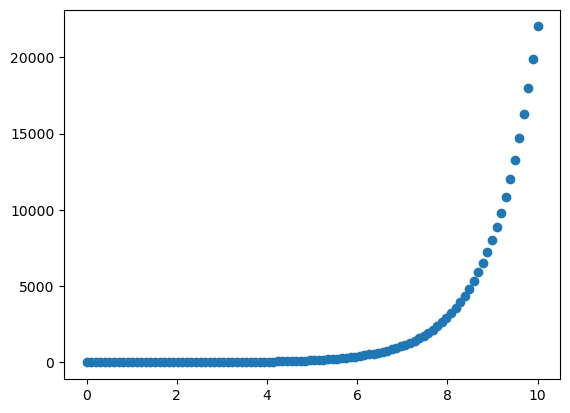

In [15]:
# Use the same data to create a scatter plot
fig, ax = plt.subplots()
ax.scatter(x, np.exp(x))
plt.show()

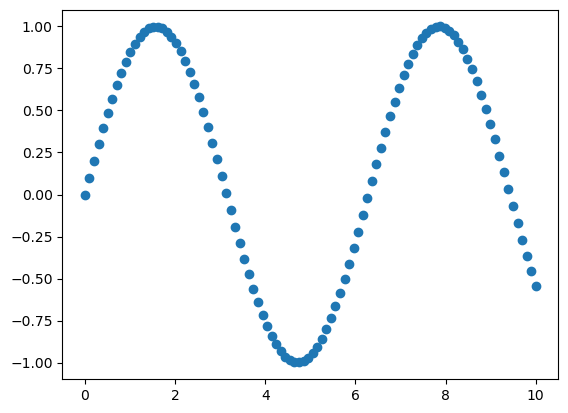

In [16]:
# Another scatter plot
fig, ax = plt.subplots()
ax.scatter(x, np.sin(x))
plt.show()

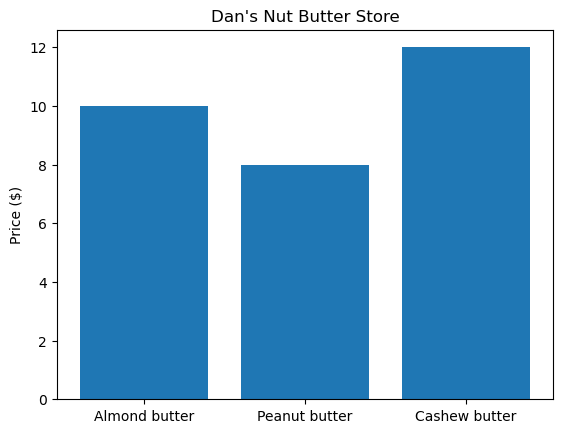

In [17]:
# Make a plot from a dictionary
nut_butter_prices = {'Almond butter': 10,
                     'Peanut butter': 8,
                     'Cashew butter': 12}
fig, ax = plt.subplots()
## Remember that `ax.bar` takes x and height as 
## **positional** arguments.
ax.bar(nut_butter_prices.keys(), nut_butter_prices.values())
ax.set(title="Dan's Nut Butter Store",
      ylabel="Price ($)")
plt.show()

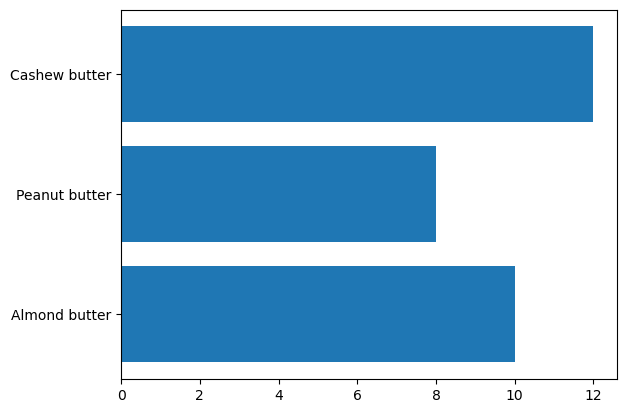

In [18]:
# Horizontal bar plot
fig, ax = plt.subplots()
ax.barh(nut_butter_prices.keys(), nut_butter_prices.values())
plt.show()

In [19]:
# The best practice seems to be to:

# - Generate a one-time 128-bit secret for the seed.
import secrets

seed = secrets.randbits(128)
seed

179524993421461603322280799276661968938

In [20]:
# **Copy and paste** this value as the **hard-coded** random number
# generator seed
rng = np.random.default_rng(seed=255754980330806113538379594848326097739)

In [21]:
# Make some data for histograms and plot it
x = rng.standard_normal(1000) ## equivalent of `np.random.randn()`
x[:10], x[-10:]

(array([-0.44119943,  0.23983538, -1.48508683,  1.67155811, -0.45568344,
         1.00258847,  0.69373234,  0.46616483,  0.31460399, -0.69119749]),
 array([-0.10473178, -0.66753084, -0.90968148,  1.32325749,  0.2629114 ,
         0.62475075, -1.57430829,  0.0332845 , -0.3743159 , -1.38164398]))

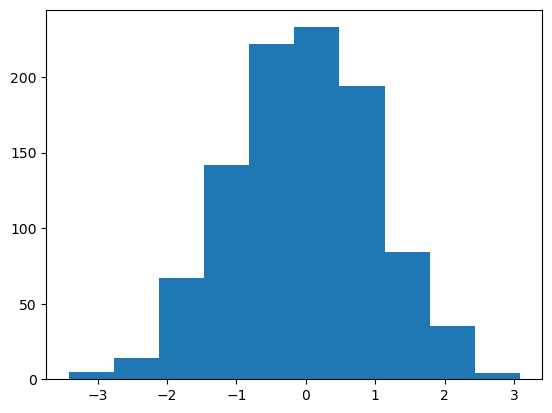

In [22]:
fig, ax = plt.subplots()
ax.hist(x)
plt.show()

### Two options for subplots

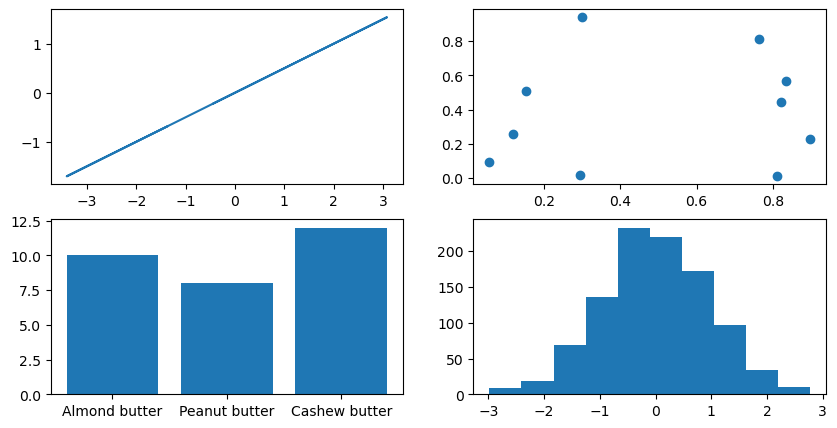

In [23]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2,
                                             ncols=2,
                                             figsize=(10, 5))

# Plot to each different axes
ax1.plot(x, x/2)
ax2.scatter(rng.random(10), rng.random(10))
ax3.bar(nut_butter_prices.keys(), nut_butter_prices.values())
ax4.hist(rng.standard_normal(1000))
plt.show()

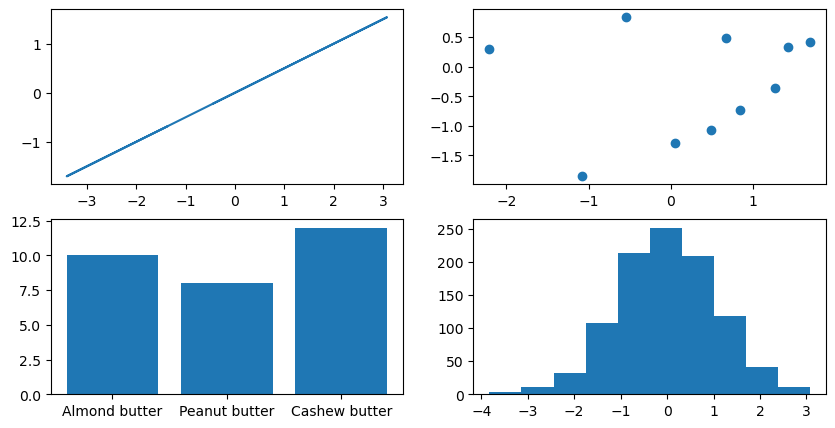

In [24]:
# Subplots option 2
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

# Plot to each different axes (by index)
ax[0, 0].plot(x, x/2)
ax[0, 1].scatter(rng.standard_normal(10), rng.standard_normal(10))
ax[1,0].bar(nut_butter_prices.keys(), nut_butter_prices.values())
ax[1,1].hist(rng.standard_normal(1000))
plt.show()

## Plotting from pandas DataFrames

In [25]:
# Not really necessary because we've already imported these packages
# Mostly a reminder
import pandas as pd
import polars as pl

In [26]:
# Make a dataframe
car_sales = pd.read_csv('data/car-sales.csv')
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


In [27]:
car_sales_pl = pl.read_csv('data/car-sales.csv')
car_sales_pl

Make,Colour,Odometer (KM),Doors,Price
str,str,i64,i64,str
"""Toyota""","""White""",150043,4,"""$4,000.00"""
"""Honda""","""Red""",87899,4,"""$5,000.00"""
"""Toyota""","""Blue""",32549,3,"""$7,000.00"""
"""BMW""","""Black""",11179,5,"""$22,000.00"""
"""Nissan""","""White""",213095,4,"""$3,500.00"""
"""Toyota""","""Green""",99213,4,"""$4,500.00"""
"""Honda""","""Blue""",45698,4,"""$7,500.00"""
"""Honda""","""Blue""",54738,4,"""$7,000.00"""
"""Toyota""","""White""",60000,4,"""$6,250.00"""


In [28]:
ts = pd.Series(rng.standard_normal(1000),
               index=pd.date_range('1/1/2020', periods=1000))
ts

2020-01-01    1.236488
2020-01-02   -0.980461
2020-01-03    1.313121
2020-01-04   -0.406143
2020-01-05   -0.571916
                ...   
2022-09-22   -0.730698
2022-09-23   -2.154979
2022-09-24    1.624140
2022-09-25    0.368595
2022-09-26    0.731684
Freq: D, Length: 1000, dtype: float64

In [29]:
ts = ts.cumsum()
ts

2020-01-01     1.236488
2020-01-02     0.256028
2020-01-03     1.569149
2020-01-04     1.163006
2020-01-05     0.591089
                ...    
2022-09-22    40.753989
2022-09-23    38.599010
2022-09-24    40.223150
2022-09-25    40.591745
2022-09-26    41.323430
Freq: D, Length: 1000, dtype: float64

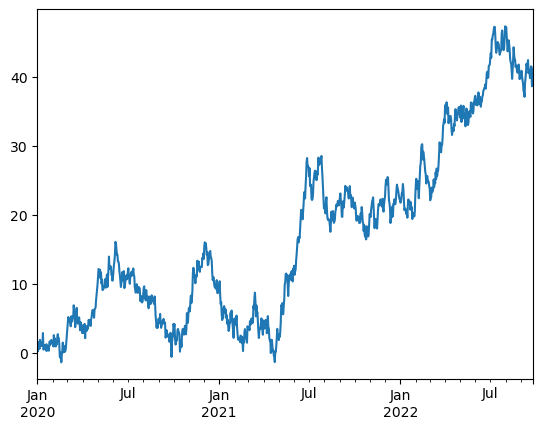

In [30]:
ts.plot()
plt.show()

In [31]:
from datetime import date
tsp = pl.DataFrame({'price': rng.standard_normal(1000),
                    'date': pl.date_range(date(2020, 1, 1), date(2022, 9, 26), "1d", eager=True)})
tsp

price,date
f64,date
-0.499695,2020-01-01
-1.801011,2020-01-02
-0.637996,2020-01-03
1.455649,2020-01-04
0.309701,2020-01-05
…,…
0.896537,2022-09-22
-1.891281,2022-09-23
0.754445,2022-09-24


In [32]:
tsp = tsp.with_columns(pl.col('price').cum_sum().alias('cum'))
tsp

price,date,cum
f64,date,f64
-0.499695,2020-01-01,-0.499695
-1.801011,2020-01-02,-2.300706
-0.637996,2020-01-03,-2.938702
1.455649,2020-01-04,-1.483053
0.309701,2020-01-05,-1.173352
…,…,…
0.896537,2022-09-22,-5.373697
-1.891281,2022-09-23,-7.264978
0.754445,2022-09-24,-6.510533


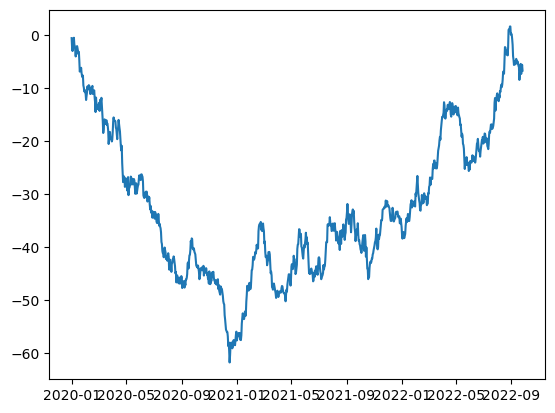

In [33]:
fig, ax = plt.subplots()
ax.plot(tsp['date'], tsp['cum'])
plt.show()

In [34]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


In [35]:
# Remove currency punctuation from items in 'Price' column
car_sales['Price'] = car_sales['Price'].str.replace('[$,.]', '', regex=True)
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,400000
1,Honda,Red,87899,4,500000
2,Toyota,Blue,32549,3,700000
3,BMW,Black,11179,5,2200000
4,Nissan,White,213095,4,350000
5,Toyota,Green,99213,4,450000
6,Honda,Blue,45698,4,750000
7,Honda,Blue,54738,4,700000
8,Toyota,White,60000,4,625000
9,Nissan,White,31600,4,970000


In [36]:
# Get the type of the first element in the "Price" column
type(car_sales['Price'][0])

str

In [37]:
# Remove the last two digits of the price; that is, remove the cents
car_sales['Price'] = car_sales['Price'].str[:-2]
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000
1,Honda,Red,87899,4,5000
2,Toyota,Blue,32549,3,7000
3,BMW,Black,11179,5,22000
4,Nissan,White,213095,4,3500
5,Toyota,Green,99213,4,4500
6,Honda,Blue,45698,4,7500
7,Honda,Blue,54738,4,7000
8,Toyota,White,60000,4,6250
9,Nissan,White,31600,4,9700


In [38]:
car_sales['Sale Date'] = pd.date_range('1/1/2024', periods=len(car_sales))
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date
0,Toyota,White,150043,4,4000,2024-01-01
1,Honda,Red,87899,4,5000,2024-01-02
2,Toyota,Blue,32549,3,7000,2024-01-03
3,BMW,Black,11179,5,22000,2024-01-04
4,Nissan,White,213095,4,3500,2024-01-05
5,Toyota,Green,99213,4,4500,2024-01-06
6,Honda,Blue,45698,4,7500,2024-01-07
7,Honda,Blue,54738,4,7000,2024-01-08
8,Toyota,White,60000,4,6250,2024-01-09
9,Nissan,White,31600,4,9700,2024-01-10


In [39]:
car_sales['Total Sales'] = car_sales['Price'].astype(int).cumsum()
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date,Total Sales
0,Toyota,White,150043,4,4000,2024-01-01,4000
1,Honda,Red,87899,4,5000,2024-01-02,9000
2,Toyota,Blue,32549,3,7000,2024-01-03,16000
3,BMW,Black,11179,5,22000,2024-01-04,38000
4,Nissan,White,213095,4,3500,2024-01-05,41500
5,Toyota,Green,99213,4,4500,2024-01-06,46000
6,Honda,Blue,45698,4,7500,2024-01-07,53500
7,Honda,Blue,54738,4,7000,2024-01-08,60500
8,Toyota,White,60000,4,6250,2024-01-09,66750
9,Nissan,White,31600,4,9700,2024-01-10,76450


In [40]:
type(car_sales['Price'][0])

str

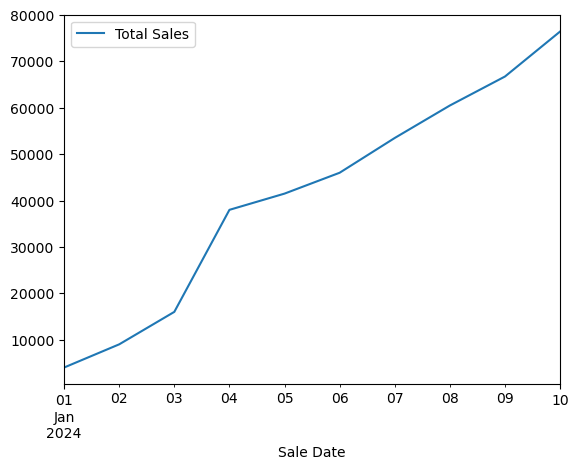

In [41]:
# Let's plot the 'Total Sales' to see what 'Total Sales' looks like
# over time
# This situation allows us to plot the data **directly**
car_sales.plot(x='Sale Date', y='Total Sales')
plt.show()



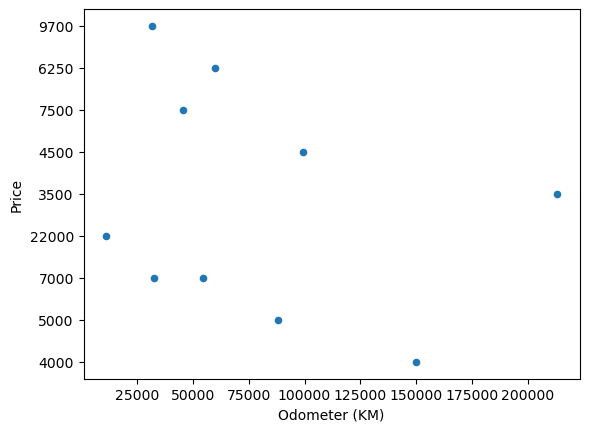

In [42]:
# Let's try a scatter plot
car_sales.plot(x='Odometer (KM)', y='Price', kind='scatter')
plt.show()

In [43]:
# Ha ha! Notice that I've executed this code earlier. It reported that
# the `type` of the 'Price' column was `str`. I said, "It works!," and
# thought no more about it. _Mea culpa_.
type(car_sales['Price'][0])

str

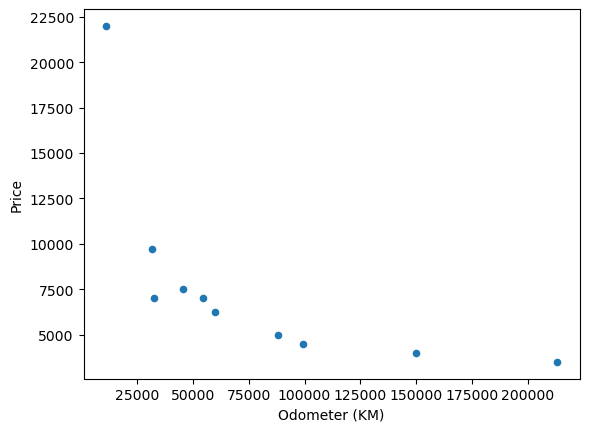

In [44]:
# Let's fix this issue by transforming the 'Price' colum to be `int`
# **before** we plot mileage against price.
car_sales['Price'] = car_sales['Price'].astype(int)

# Plot scatter plot with 'Price' column as **numeric**.
car_sales.plot(x='Odometer (KM)', y='Price', kind='scatter')
plt.show()

# **Much** better!

In [45]:
# Let's try similar plots on another data set
heart_disease = pd.read_csv('data/heart-disease.csv')
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


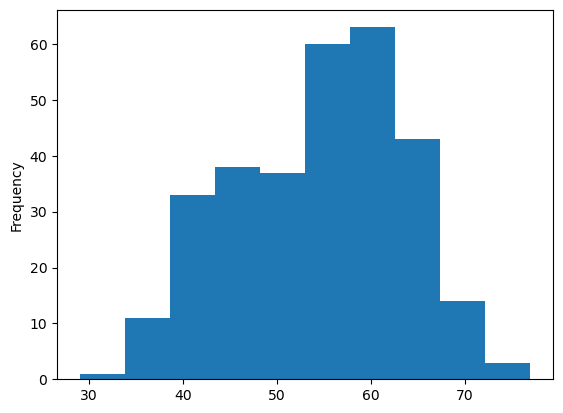

In [46]:
heart_disease['age'].plot.hist();

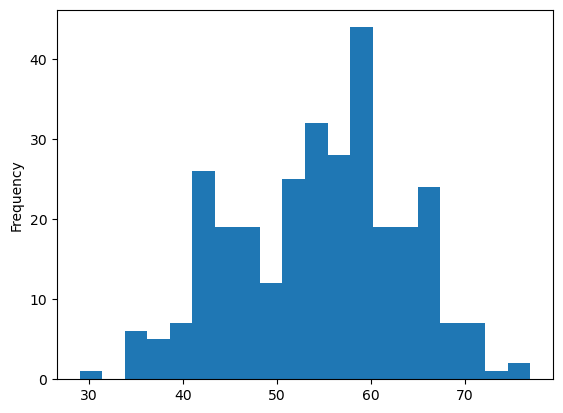

In [47]:
heart_disease['age'].plot.hist(bins=20);

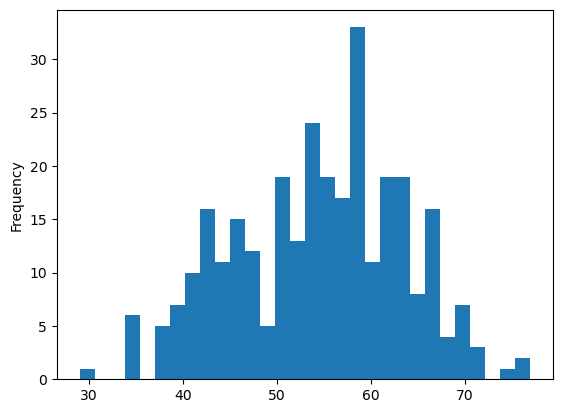

In [48]:
heart_disease['age'].plot.hist(bins=30);

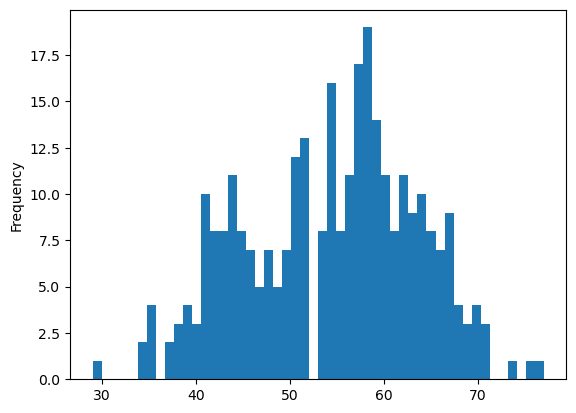

In [49]:
heart_disease['age'].plot.hist(bins=50);

# Notice the we continue to have a strong peak at the mean
# and, perhaps, we see some outliers.

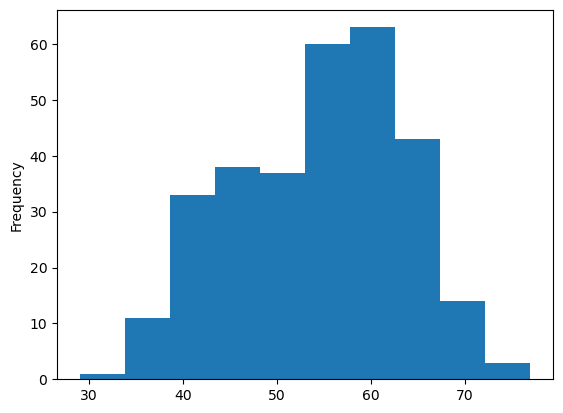

In [50]:
heart_disease['age'].plot.hist();

In [51]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


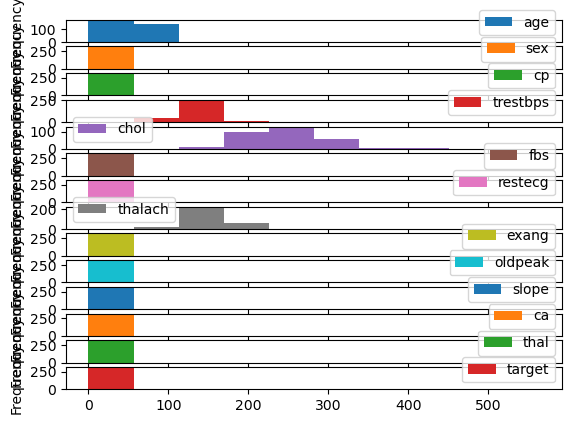

In [52]:
# Let's plot **every** column in a set of histograms in one plot
heart_disease.plot.hist(subplots=True);

# Note that finding how to use the `subplots` argument is a 
# bit difficult.

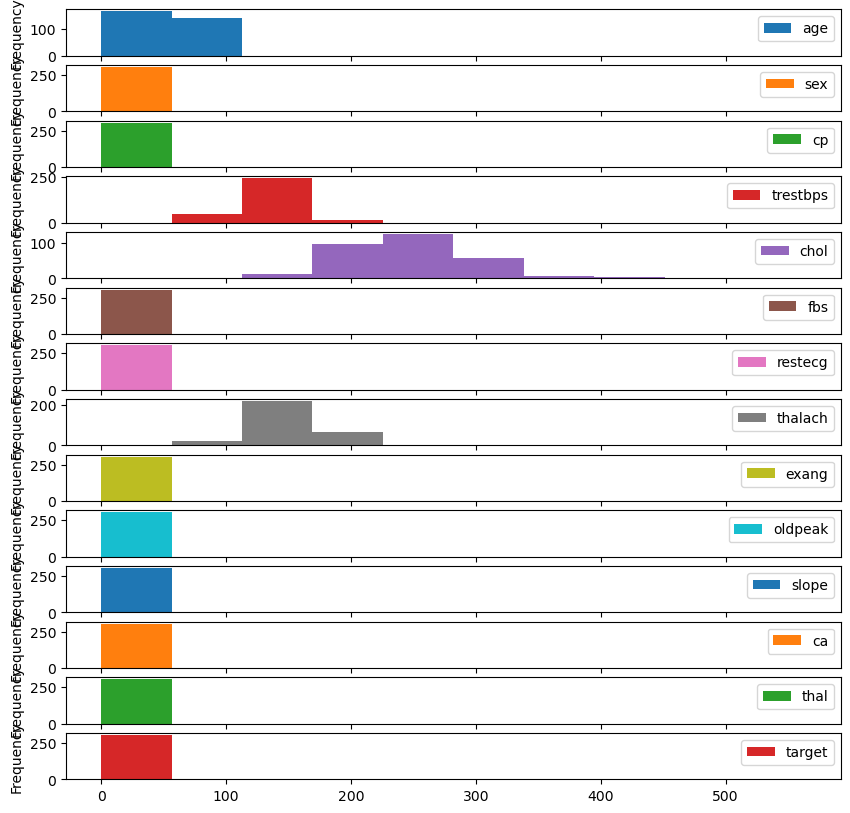

In [53]:
# Plotting as we did produces a very "busy" plot. Many different
# plot components overlap. These issues make it difficult for a
# person to "grok" this plot.

# Let's see if we can address these problems.
heart_disease.plot.hist(figsize=(10, 10), subplots=True);

# This change addresses the overlap in the plot, but the text on
# the many y-axes overlaps.

Exception: AttributeError: Rectangle.set() got an unexpected keyword argument 'ytitle'


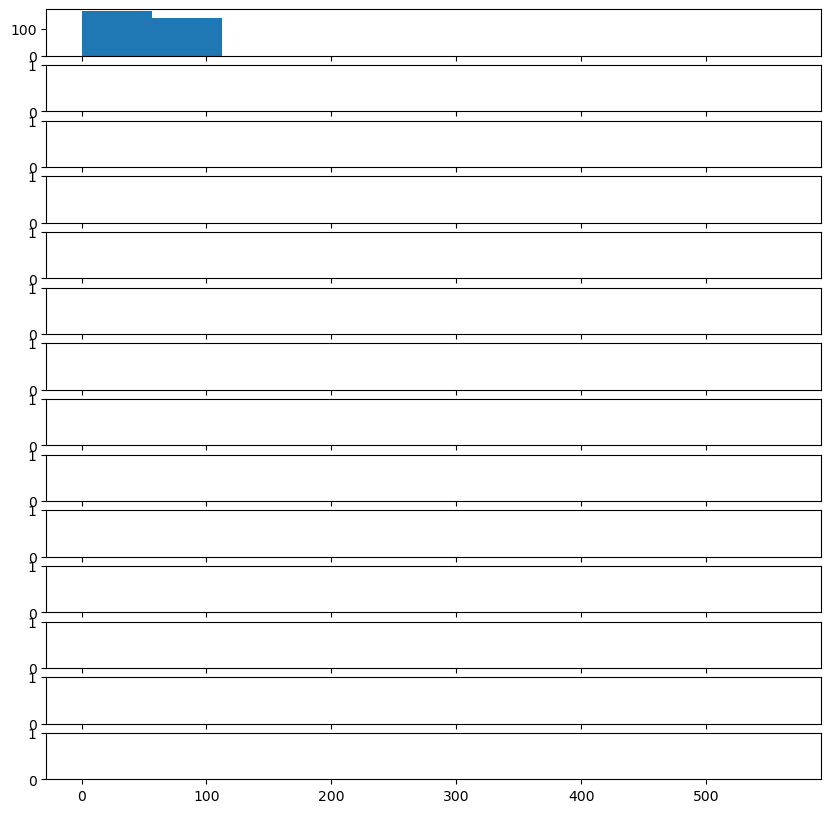

In [54]:
try:
    heart_disease.plot.hist(ytitle='Frequency', ylabels='', 
                            figsize=(10, 10), subplots=True)
except AttributeError as ae:
    print(f'Exception: {type(ae).__name__}: {ae}')

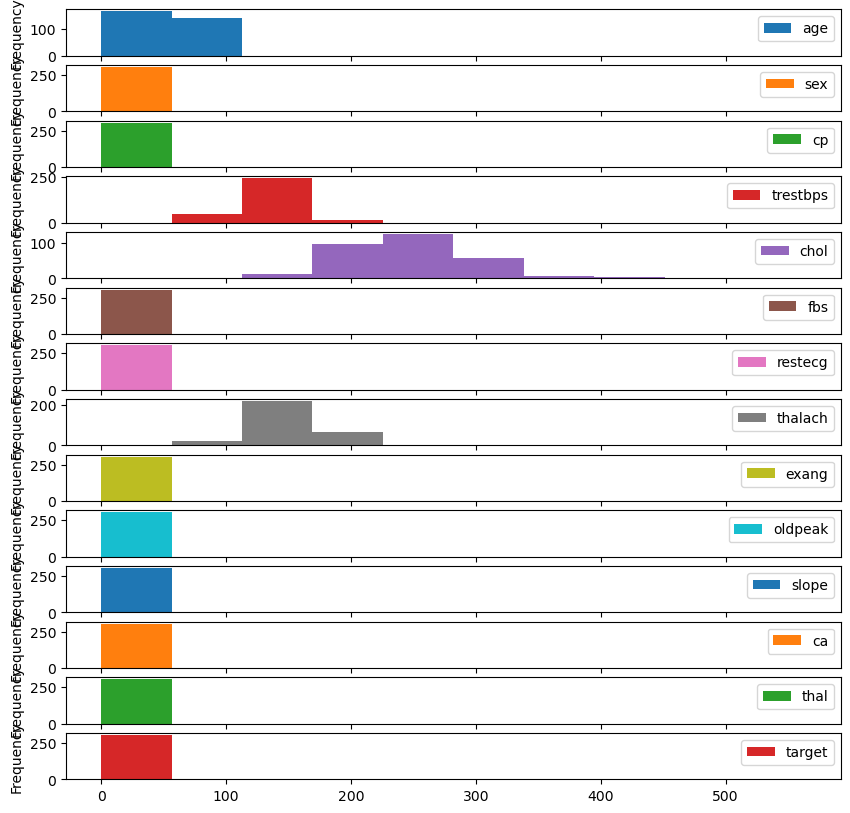

In [55]:
heart_disease.plot.hist(figsize=(10, 10), subplots=True)
fig.supylabel('Frequency')
plt.show()

# I may need to figure out how to suppress the individual y-labels later.

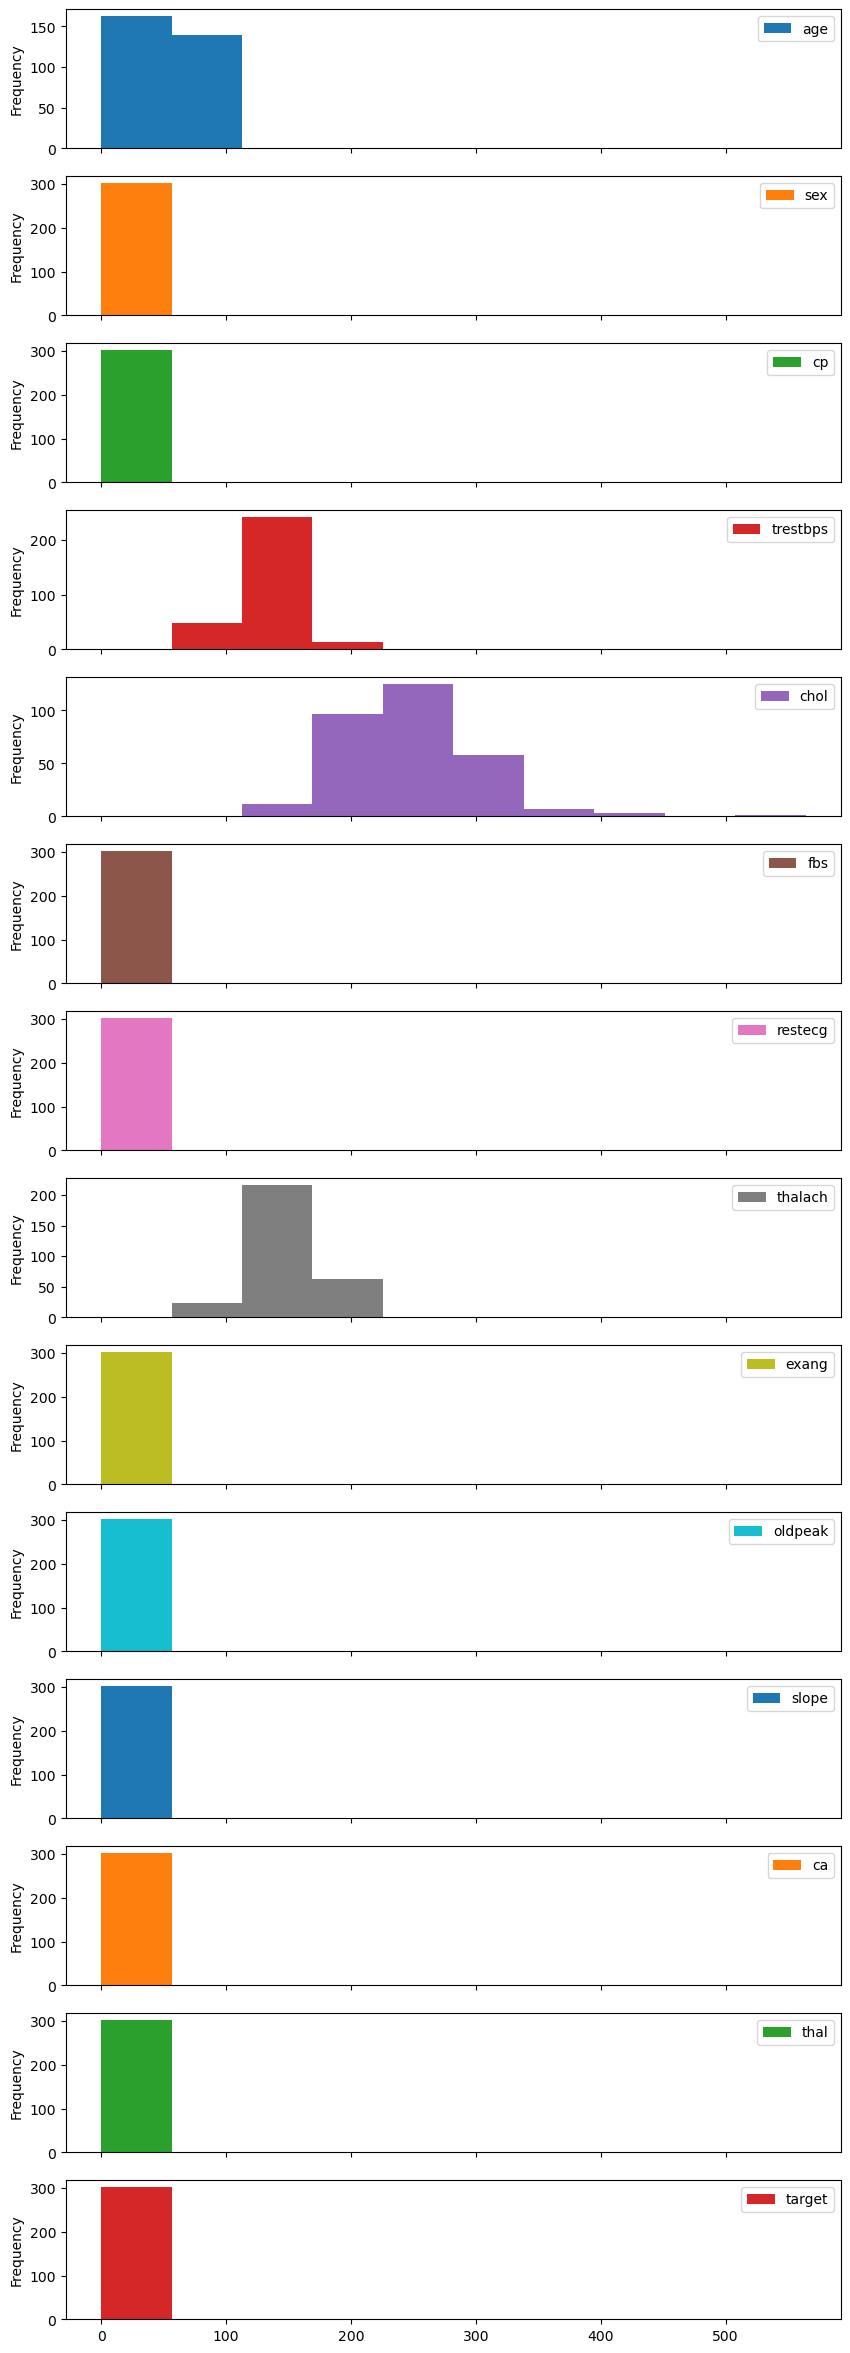

In [56]:
heart_disease.plot.hist(figsize=(10, 30), subplots=True);

The previous plot is not ideal. Many of the plats appear to have all 
the data bunched. This behavior results from every plot **sharing** 
the same x-axis. We'll look at how to fix this issue in the 
next video using the object-oriented plotting methods.

### Which method should one use (`pyplot` vs `matplotlib` object-oriented method)?

- When plotting something quickly, okay to use the `pyplot` classmethod
- When plotting something more advanced, use the `matplotlib` object-oriented method

In [58]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [59]:
# Create a subset of our data: patients over 50
over_50 = heart_disease[heart_disease['age'] > 50]
over_50.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1


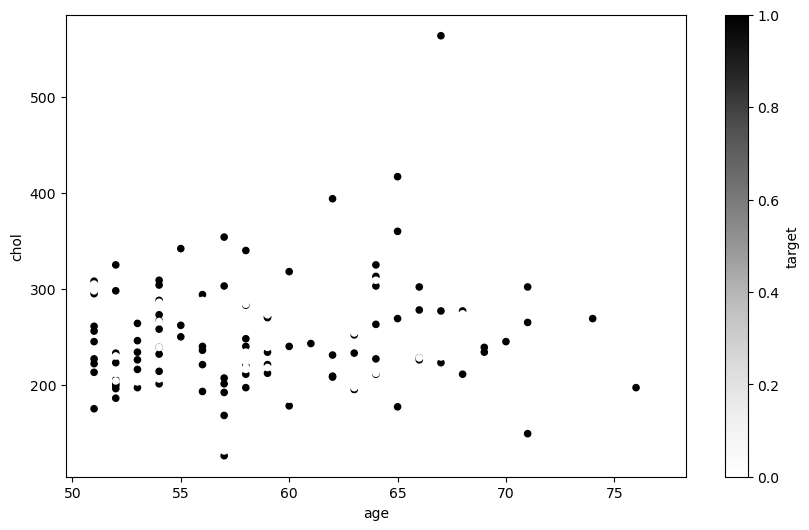

In [66]:
# Start with a scatter plot of age versus cholesterol.
# We'll use the `pyplot` plotting method.
over_50.plot(kind='scatter',
             x='age',
             y='chol',
             c='target',
             figsize=(10, 6),);

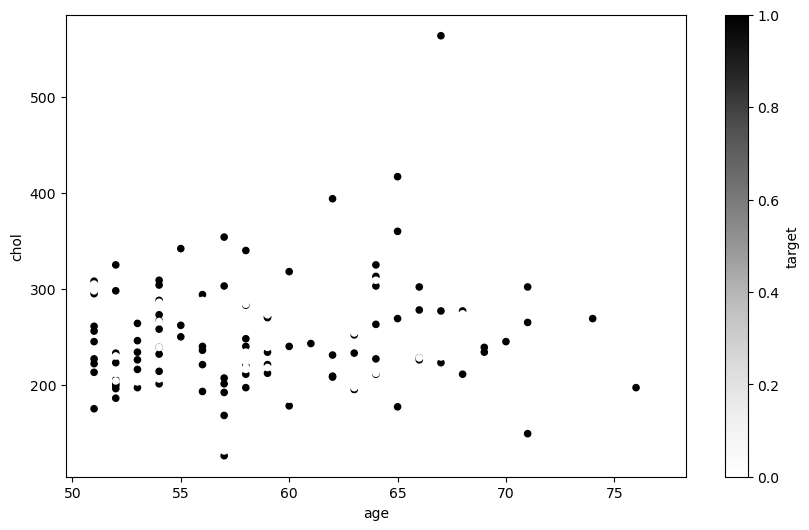

In [65]:
# Let's try the OO plotting methods
fig, ax = plt.subplots(figsize=(10, 6))
over_50.plot(kind='scatter',
             x='age',
             y='chol',
             c='target',
             ax=ax)
plt.show()

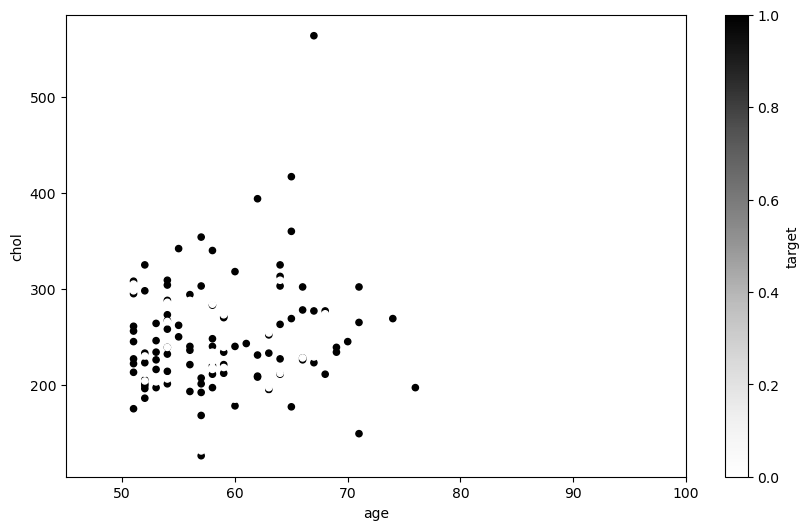

In [67]:
# Let's try some additional adjustments (setting the x limits)
fig, ax = plt.subplots(figsize=(10, 6))
over_50.plot(kind='scatter',
             x='age',
             y='chol',
             c='target',
             ax=ax)
ax.set_xlim([45, 100])
plt.show()


Setting specific limits on the x-axis results in more whitespace
around the plot, but does not seem to be a more informative plot.

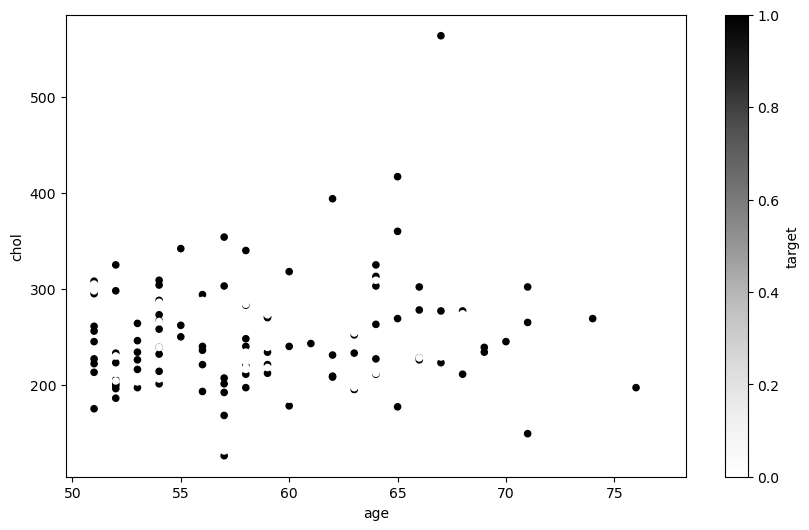

In [68]:
# Let's return to our original settings
fig, ax = plt.subplots(figsize=(10, 6))
over_50.plot(kind='scatter',
             x='age',
             y='chol',
             c='target',
             ax=ax)
plt.show()